# Notebook 01 — EDA & Preprocessing
**Project:** Automated detection of cervical cancer using deep learning on Pap smear images.

This notebook walks through the full exploratory data analysis and preprocessing pipeline before model training.

---
## 0. Data Acquisition

**Dataset:** A curated dataset of conventional Pap smear microscopy images.
- **Source:** https://data.mendeley.com/datasets/rnfyhrtfkw/1
- **Instructions:** Download `CPSMI2025.zip` and upload it to `MyDrive/data/` in Google Drive.
### Environment Setup & Directory Initialization
This cell conditionally mounts Google Drive (if running on Google Colab) or defaults to the local directory, establishes the project directories (`data`, `models`, `reports/figures`), and ensures they are initialized.


In [1]:
import os
try:
    import google.colab
    from google.colab import drive
    drive.mount('/content/drive')
    PROJECT  = '/content/drive/MyDrive/cervical-cancer-project'
except ImportError:
    PROJECT  = '.'

DATA_DIR = os.path.join(PROJECT, 'data')
MODEL_DIR = os.path.join(PROJECT, 'models')
FIG_DIR  = os.path.join(PROJECT, 'reports', 'figures')

for d in [DATA_DIR, MODEL_DIR, FIG_DIR]:
    os.makedirs(d, exist_ok=True)


Mounted at /content/drive


### Dataset Extraction
Extracts the raw Mendeley dataset zip file (`CPSMI2025.zip`) into a local raw data subfolder for processing, skipping extraction if the dataset has already been unzipped.


In [2]:
import zipfile

zip_path = '/content/drive/MyDrive/Data/CPSMI2025.zip' if os.path.exists('/content/drive') else 'CPSMI2025.zip'
raw_extract_path = os.path.join(DATA_DIR, 'raw')

if not os.path.exists(raw_extract_path):
    if os.path.exists(zip_path):
        print(f'Extracting {zip_path}...')
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(raw_extract_path)
        print('Done.')
    else:
        print(f'Zip file not found at {zip_path}. Please upload it first.')
else:
    print('Already extracted.')


Already extracted.


---
## 1. Dataset Overview

### Dynamic Dataset Path Configuration
Searches the extracted directories recursively to detect the exact location of the target class folders (`cancer`, `lesion`, `normal`, `others`), mitigating any nested directory quirks from extraction.


In [12]:
import os

base_extracted = os.path.join(DATA_DIR, 'raw')
nested_path = os.path.join(base_extracted, 'CPSMI2025')
if os.path.exists(os.path.join(nested_path, 'CPSMI2025')):\
    DATASET_PATH = os.path.join(nested_path, 'CPSMI2025')
elif os.path.exists(nested_path):\
    DATASET_PATH = nested_path
else:\
    DATASET_PATH = base_extracted


# Count images per class recursively
class_counts = {}
for cls in sorted(os.listdir(DATASET_PATH)):
    cls_dir = os.path.join(DATASET_PATH, cls)
    if os.path.isdir(cls_dir):
        count = sum(len(files) for _, _, files in os.walk(cls_dir))
        class_counts[cls] = count

total = sum(class_counts.values())
print(f'Total images  : {total}')
print(f'Classes       : {list(class_counts.keys())}')
print(f'Class counts  : {class_counts}')

Total images  : 2169
Classes       : ['cancer', 'lesion', 'normal', 'others']
Class counts  : {'cancer': 610, 'lesion': 677, 'normal': 741, 'others': 141}


---
## 2. Class Distribution

### Dataset Statistics & Class Distribution
Scans the source dataset to count the total number of images in each class folder, verifying the raw class balance before proceeding.
### Visualizing Class Imbalance
Plots a horizontal bar chart summarizing the image counts per class to visually evaluate class imbalance and guide our split stratifications.


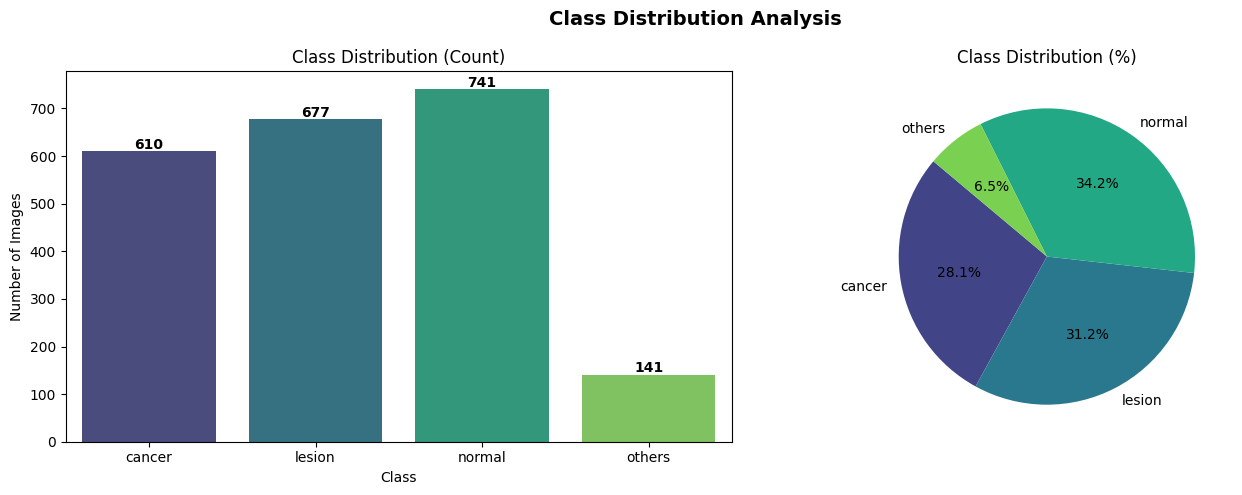

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()),
            palette='viridis', ax=axes[0], hue=list(class_counts.keys()), legend=False)
axes[0].set_title('Class Distribution (Count)')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Number of Images')
for i, v in enumerate(class_counts.values()):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values(), labels=class_counts.keys(),
            autopct='%1.1f%%', startangle=140, colors=sns.color_palette('viridis', len(class_counts)))
axes[1].set_title('Class Distribution (%)')

plt.suptitle('Class Distribution Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'Class Distribution Analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

The dataset is made of 2169 images across four classes and it is fairly balanced.

---
## 3. Sample Image Visualization
Displaying 3 random raw images from each class.
### Microscopic Sample Inspection
Loads and displays representative sample slide images from each of the four categories to inspect the raw cell morphology, resolution, and staining profiles.


In [5]:
import random
from PIL import Image

N_SAMPLES = 3
classes = list(class_counts.keys())
fig, axes = plt.subplots(len(classes), N_SAMPLES, figsize=(N_SAMPLES*4, len(classes)*4))

for row, cls in enumerate(classes):
    cls_dir = os.path.join(DATASET_PATH, cls)
    all_paths = []
    for r, _, files in os.walk(cls_dir):
        for f in files:
            if f.lower().endswith(('.png','.jpg','.jpeg','.bmp','.tif','.tiff')):
                all_paths.append(os.path.join(r, f))
    samples = random.sample(all_paths, min(N_SAMPLES, len(all_paths)))
    for col, path in enumerate(samples):
        img = Image.open(path).convert('RGB')
        axes[row][col].imshow(img)
        axes[row][col].set_title(cls if col == 0 else '')
        axes[row][col].axis('off')

plt.suptitle('Sample Images per Class (Raw)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'Sample_raw_images.png'), dpi=150, bbox_inches='tight')
plt.show()

Output hidden; open in https://colab.research.google.com to view.

The PapSmear images are stained with purple stain however we observe a staining variation of bluish-green background in cancerous and lesioned cells. Some cell slides are dense while others are sparse.

---
## 4. Image Statistics
### 4a. Size Analysis (Min, Max, Average, Unique Sizes)



,Class,Count,Min Size,Max Size,Avg Size,Unique Sizes
0,cancer,610,2028x1520,2028x1520,2028.0x1520.0,1
1,lesion,677,2028x1520,2028x1520,2028.0x1520.0,1
2,normal,741,2028x1520,2028x1520,2028.0x1520.0,1
3,others,141,2028x1520,2028x1520,2028.0x1520.0,1


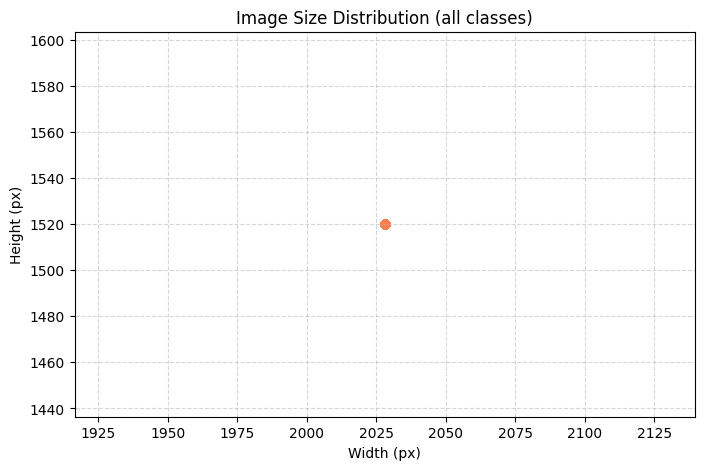

In [6]:
import numpy as np
import pandas as pd

size_stats = []
all_w, all_h = [], []

for cls in classes:
    cls_dir = os.path.join(DATASET_PATH, cls)
    paths = []
    for r, _, files in os.walk(cls_dir):
        for f in files:
            if f.lower().endswith(('.png','.jpg','.jpeg','.bmp','.tif','.tiff')):
                paths.append(os.path.join(r, f))
    ws, hs, uniq = [], [], set()
    for p in paths:
        with Image.open(p) as img:
            w, h = img.size
            ws.append(w); hs.append(h); uniq.add((w,h))
            all_w.append(w); all_h.append(h)
    size_stats.append({'Class': cls, 'Count': len(ws),
                       'Min Size': f'{min(ws)}x{min(hs)}',
                       'Max Size': f'{max(ws)}x{max(hs)}',
                       'Avg Size': f'{np.mean(ws):.1f}x{np.mean(hs):.1f}',
                       'Unique Sizes': len(uniq)})

df = pd.DataFrame(size_stats)
display(df)

plt.figure(figsize=(8,5))
plt.scatter(all_w, all_h, alpha=0.3, color='coral')
plt.title('Image Size Distribution (all classes)')
plt.xlabel('Width (px)'); plt.ylabel('Height (px)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

The images are of standardized size 2028 x 1520 pixels

### 4b. Pixel Intensity Analysis (Mean & Std per Channel)
### Spatial Resolution Profiling
Samples a subset of images across classes to inspect their varying pixel resolutions (height, width, channels), confirming the necessity of resizing.

In [7]:
# Sample up to 50 images per class for pixel analysis (fast)
channel_stats = []

for cls in classes:
    cls_dir = os.path.join(DATASET_PATH, cls)
    paths = []
    for r, _, files in os.walk(cls_dir):
        for f in files:
            if f.lower().endswith(('.png','.jpg','.jpeg','.bmp','.tif','.tiff')):
                paths.append(os.path.join(r, f))
    sample = random.sample(paths, min(50, len(paths)))
    r_vals, g_vals, b_vals = [], [], []
    for p in sample:
        arr = np.array(Image.open(p).convert('RGB')) / 255.0
        r_vals.append(arr[:,:,0].mean())
        g_vals.append(arr[:,:,1].mean())
        b_vals.append(arr[:,:,2].mean())
    channel_stats.append({'Class': cls,
                          'R Mean': f'{np.mean(r_vals):.3f}', 'R Std': f'{np.std(r_vals):.3f}',
                          'G Mean': f'{np.mean(g_vals):.3f}', 'G Std': f'{np.std(g_vals):.3f}',
                          'B Mean': f'{np.mean(b_vals):.3f}', 'B Std': f'{np.std(b_vals):.3f}'})

display(pd.DataFrame(channel_stats))

,Class,R Mean,R Std,G Mean,G Std,B Mean,B Std
0,cancer,0.621,0.090,0.592,0.107,0.622,0.108
1,lesion,0.633,0.079,0.587,0.081,0.643,0.077
2,normal,0.589,0.047,0.576,0.044,0.590,0.047
3,others,0.621,0.070,0.569,0.087,0.635,0.063


All image classes show a moderate mean intensity across all the RBG channels. The lesion class records the highest mean across all the 3 channels. Cancer class has a high standard deviation for the green channel which could introduce noise in the data. This will be handled in transformations.

---
## 5. Stain Variation Analysis
Pap smear images use the **Papanicolaou stain**. The distinct magenta/purple (hematoxylin) and pink/orange (eosin) tones are critical diagnostic features. This section visualizes per-class average color profiles to confirm stain variation across categories.

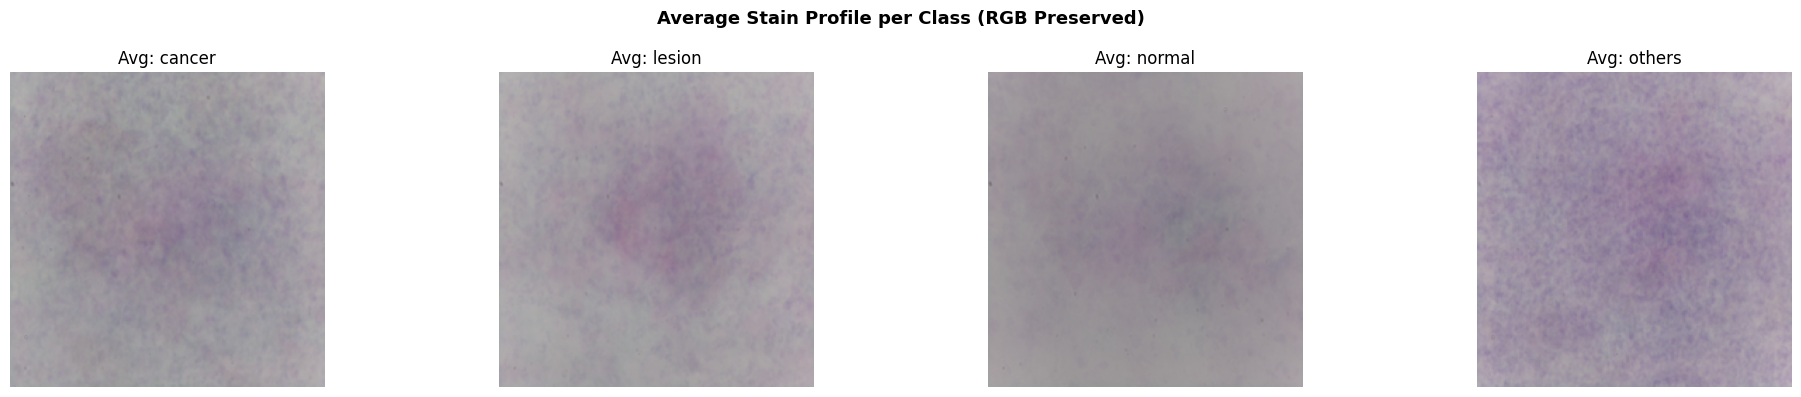

In [8]:
fig, axes = plt.subplots(1, len(classes), figsize=(5*len(classes), 4))

for i, cls in enumerate(classes):
    cls_dir = os.path.join(DATASET_PATH, cls)
    paths = []
    for r, _, files in os.walk(cls_dir):
        for f in files:
            if f.lower().endswith(('.png','.jpg','.jpeg','.bmp','.tif','.tiff')):
                paths.append(os.path.join(r, f))
    sample = random.sample(paths, min(30, len(paths)))
    avg_img = np.zeros((224, 224, 3))
    for p in sample:
        avg_img += np.array(Image.open(p).convert('RGB').resize((224,224))) / 255.0
    avg_img /= len(sample)
    axes[i].imshow(np.clip(avg_img, 0, 1))
    axes[i].set_title(f'Avg: {cls}')
    axes[i].axis('off')

plt.suptitle('Average Stain Profile per Class (RGB Preserved)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Preprocessing Pipeline
We define separate transform pipelines for train, validation, and test sets.
- **Resize:** All images standardized to 224×224 px input requirements for pretrained models and reduce memory consumption
- **RGB Preserved:** Stain colors are critical diagnostic features — no grayscale conversion
- **Normalize:** ImageNet mean/std used for compatibility with pretrained ResNet18

In [9]:
import torch
from torchvision import transforms

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}
print('Transform pipelines defined.')


Transform pipelines defined.


---
## 7. Augmentation Visualization
Showing the same image before and after training augmentations (flip + rotation).
### Preprocessing & Data Augmentation Setup
Defines the PyTorch transform pipelines. The training pipeline applies spatial resizing, flips, rotations, and color jitter to prevent overfitting, while the validation/test pipeline applies only resizing and normalization.


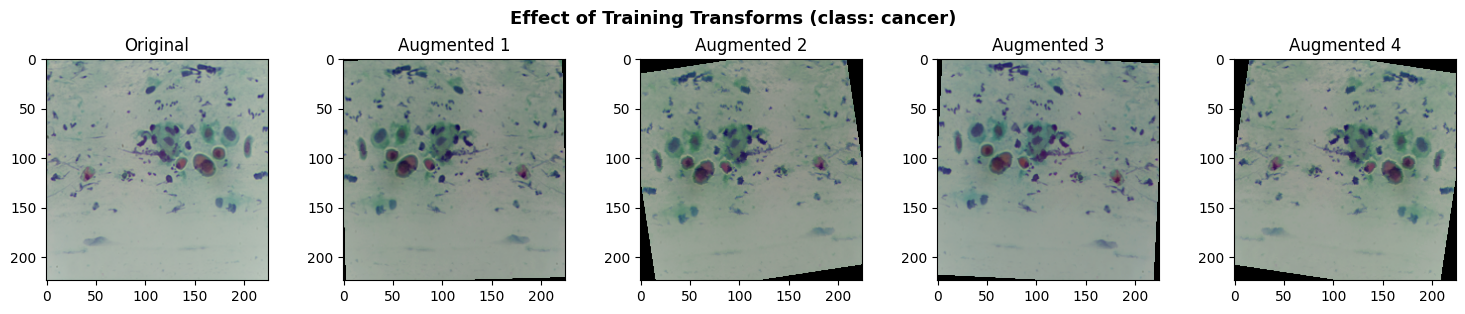

In [10]:
def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = tensor.permute(1, 2, 0).numpy()
    img  = std * img + mean
    return np.clip(img, 0, 1)

# Pick one real image from the first class
sample_cls = classes[0]
cls_dir = os.path.join(DATASET_PATH, sample_cls)
sample_paths = []
for r, _, files in os.walk(cls_dir):
    for f in files:
        if f.lower().endswith(('.png','.jpg','.jpeg','.bmp','.tif','.tiff')):
            sample_paths.append(os.path.join(r, f))
img = Image.open(random.choice(sample_paths)).convert('RGB')

fig, axes = plt.subplots(1, 5, figsize=(15, 3))
axes[0].imshow(img.resize((224, 224)))
axes[0].set_title('Original')
for i in range(1, 5):
    augmented = data_transforms['train'](img)
    axes[i].imshow(denormalize(augmented))
    axes[i].set_title(f'Augmented {i}')
plt.suptitle(f'Effect of Training Transforms (class: {sample_cls})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'Augmented_Images_EDA_Transforms.png'), dpi=150, bbox_inches='tight')
plt.show()



Visualizing augmented images show that  the flips and rotation are realistic.  The visualizations confirm that random horizontal and vertical flips produce valid cell orientations, consistent with the natural variability in cell positioning across Pap smear slides. Random rotation introduces subtle angular variation without distorting cellular morphology beyond clinical recognition.

---
## 8. Train / Val / Test Split
The raw dataset has no pre-defined splits. We create a **70/15/15** split programmatically using a fixed random seed (42) for reproducibility.

### Stratified Train/Val/Test Folder Creation
Performs a stratified split ($70\%$ training, $15\%$ validation, $15\%$ test) on the images of each class using a random seed of $42$, and copies files into dedicated physical subdirectories.


In [15]:
from sklearn.model_selection import train_test_split
import shutil
import os


# Partition and copy files
for cls in classes:
    cls_dir = os.path.join(DATASET_PATH, cls)
    if not os.path.isdir(cls_dir):
        continue

    # ── 1. SCAN RECURSIVELY (Scan all nested folders) ────────────────────────
    images = []
    for root, _, files in os.walk(cls_dir):
        for f in files:
            if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')):
                # Get relative path from class folder root
                rel_path = os.path.relpath(os.path.join(root, f), cls_dir)
                images.append(rel_path)

    n_total = len(images)
    if n_total == 0:
        print(f'Warning: No images found in {cls_dir}. Skipping.')
        continue

    print(f'Partitioning class {cls} with {n_total} images (nested)...')

    # Stratified 70/15/15 split
    if n_total == 1:
        train_imgs, val_imgs, test_imgs = images, [], []
    elif n_total == 2:
        train_imgs, val_imgs, test_imgs = [images[0]], [images[1]], []
    else:
        train_imgs, val_test_imgs = train_test_split(images, test_size=0.3, random_state=42)
        if len(val_test_imgs) >= 2:
            val_imgs, test_imgs = train_test_split(val_test_imgs, test_size=0.5, random_state=42)
        else:
            val_imgs, test_imgs = val_test_imgs, []

    # ── 2. FLATTEN AND COPY TO SPLIT DIRECTORIES ─────────────────────────────
    def copy_flat(img_list, dest_split):
        dest_dir = os.path.join(DATA_DIR, dest_split, cls)
        for rel_path in img_list:
            src_path = os.path.join(cls_dir, rel_path)
            # Replace path slashes with underscores to flatten and prevent collisions
            flat_name = rel_path.replace(os.sep, '_')
            shutil.copy(src_path, os.path.join(dest_dir, flat_name))

    copy_flat(train_imgs, 'train')
    copy_flat(val_imgs, 'val')
    copy_flat(test_imgs, 'test')

print('Physical train/val/test split completed successfully.')


Partitioning class cancer with 610 images (nested)...
Partitioning class lesion with 677 images (nested)...
Partitioning class normal with 741 images (nested)...
Partitioning class others with 141 images (nested)...
Physical train/val/test split completed successfully.


---
## 9. Final Dataset Summary


Scans the generated directory structure to count the images in each split and outputs a comprehensive summary table detailing image dimensions, augmentations, and dataset splits.


In [16]:
import pandas as pd

# Count the physically copied files inside train, val, and test splits
train_size = sum(len(files) for _, _, files in os.walk(os.path.join(DATA_DIR, 'train')))
val_size   = sum(len(files) for _, _, files in os.walk(os.path.join(DATA_DIR, 'val')))
test_size  = sum(len(files) for _, _, files in os.walk(os.path.join(DATA_DIR, 'test')))

summary = {
    'Total Images': [total],
    'Classes': [len(class_counts)],
    'Train Set': [train_size],
    'Val Set':   [val_size],
    'Test Set':  [test_size],
    'Image Size (after resize)': ['224 x 224'],
    'Color Mode': ['RGB (stain preserved)'],
    'Augmentations': ['HFlip, VFlip, Rotation(10°), ColorJitter — Train only'],
    'Normalization': ['ImageNet mean/std'],
    'Random Seed': [42]
}
display(pd.DataFrame(summary).T.rename(columns={0: 'Value'}))


,Value
Total Images,2169
Classes,4
Train Set,1516
Val Set,325
Test Set,328
Image Size (after resize),224 x 224
Color Mode,RGB (stain preserved)
Augmentations,"HFlip, VFlip, Rotation(10°), ColorJitter — Tra..."
Normalization,ImageNet mean/std
Random Seed,42
